# Entregável 2 — Avaliação da Qualidade do Sinal (Signal Quality Index – SQI)

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Lessa & Matheus Rocha  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.

---

## Objetivo

Este notebook implementa a etapa de **Avaliação da Qualidade do Sinal (SQI)** do pipeline da disciplina, dando continuidade direta ao **Entregável 1**, no qual foram identificadas visualmente as seguintes ocorrências nos sinais brutos do dataset PTB-XL:

- **Drift de baseline** (componentes de baixíssima frequência, < 0,5 Hz)
- **Ruído de linha** (interferência 50/60 Hz)
- **Ausência de saturação evidente** nos registros analisados

Neste entregável, esses fenômenos são **quantificados rigorosamente** por meio de métricas objetivas de SQI. O objetivo não é limpar os dados — isso será feito no **Entregável 4** —, mas sim caracterizar a qualidade do sinal bruto, definir critérios de aceitação e rejeição, e construir uma base sólida para as etapas subsequentes (Entregáveis 3 a 10).

### Métricas implementadas

| Métrica | Domínio | O que detecta |
|---------|---------|---------------|
| **SNR** (Signal-to-Noise Ratio) | Tempo | Relação sinal/ruído global |
| **Kurtosis** | Estatístico | Artefatos impulsivos / eletrodo solto |
| **Skewness** | Estatístico | Assimetria / saturação de sinal |
| **Entropia Espectral** | Frequência | Complexidade espectral / ruído de banda larga |
| **Potência em 50/60 Hz** | Frequência | Interferência de rede elétrica |
| **Detecção de Saturação** | Amplitude | Clipping do ADC |
| **Índice de Drift de Baseline** | Tempo/Freq | Variações lentas (< 0,5 Hz) |
| **SQI Composto** | Agregado | Score final 0–100 por derivação |

---

> **Nota metodológica:** O SQI é calculado sobre os sinais **brutos** (sem filtragem), preservando as características originais de aquisição documentadas no Entregável 1. O cálculo será feito com o dataset inteiro para garantir reprodutibilidade completa.


---
## 1. Configuração do Ambiente e Imports


In [2]:
# ── Dependências ────────────────────────────────────────────────────────────
# !pip install wfdb scipy pandas numpy matplotlib seaborn tqdm --quiet

import os
import ast
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import wfdb

from scipy import signal as sp_signal
from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Estilo global ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CORES = {
    'primaria':   '#1a3a5c',
    'secundaria': '#e74c3c',
    'ok':         '#2ecc71',
    'aviso':      '#f39c12',
    'ruim':       '#e74c3c',
    'info':       '#3498db',
    'neutro':     '#95a5a6',
}

# ── Caminhos ────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
FIG_DIR  = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Parâmetros globais ───────────────────────────────────────────────────────
FS          = 500          # Taxa de amostragem (HR, justificada no Entregável 1)
N_AMOSTRA   = None         # None = dataset completo (21.799 registros)
SEED        = 42
DERIVACOES  = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF',
               'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)


print(' Configuração concluída.')
print(f'   Dados       : {DATA_DIR.resolve()}')
print(f'   Figuras     : {FIG_DIR.resolve()}')
print(f'   Outputs     : {OUT_DIR.resolve()}')
print(f'   Fs = {FS} Hz | Amostra = DATASET COMPLETO | Seed = {SEED}')


 Configuração concluída.
   Dados       : C:\Users\josel\OneDrive\Documentos\Biossinais\data\ptb-xl\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
   Figuras     : C:\Users\josel\OneDrive\Documentos\Biossinais\entregaveis\entregavel-2\figuras
   Outputs     : C:\Users\josel\OneDrive\Documentos\Biossinais\entregaveis\entregavel-2\outputs
   Fs = 500 Hz | Amostra = DATASET COMPLETO | Seed = 42


---
## 2. Carregamento dos Metadados e Seleção da Amostra

Carregamos o arquivo `ptbxl_database.csv` (mesmo utilizado no Entregável 1) e utilizamos **todos os 21.799 registros** do dataset PTB-XL, garantindo cobertura completa de todas as superclasses diagnósticas e dispositivos de aquisição.

In [3]:
# ── Metadados ────────────────────────────────────────────────────────────────
metadata_path = DATA_DIR / 'ptbxl_database.csv'
df_meta = pd.read_csv(metadata_path, index_col='ecg_id')
df_meta['scp_codes'] = df_meta['scp_codes'].apply(ast.literal_eval)

# Usar todos os registros do dataset
ids_amostra = df_meta.index.values.copy()
ids_amostra.sort()

print(f'Total de registros no dataset : {len(df_meta):,}')
print(f'Registros para análise SQI    : {len(ids_amostra):,}')
print(f'Primeiros 5 IDs: {ids_amostra[:5]}')
print(f'Últimos  5 IDs: {ids_amostra[-5:]}')


Total de registros no dataset : 21,799
Registros para análise SQI    : 21,799
Primeiros 5 IDs: [1 2 3 4 5]
Últimos  5 IDs: [21833 21834 21835 21836 21837]


---
## 3. Funções de Cálculo das Métricas SQI

Cada função abaixo implementa uma métrica específica de qualidade de sinal, com documentação da fundamentação teórica e dos limiares de decisão adotados.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 3.1  SNR — Signal-to-Noise Ratio
# ════════════════════════════════════════════════════════════════════════════
# Estimativa de SNR baseada na razão entre a potência do sinal 'de interesse'
# (banda 0,5–40 Hz) e a potência do ruído residual (> 100 Hz).
# Referência: Clifford et al. (2006) "Advanced Methods and Tools for ECG Data Analysis".
#
# Limiares adotados:
#   SNR >= 20 dB → qualidade BOA
#   10 <= SNR < 20 dB → qualidade ACEITÁVEL
#   SNR < 10 dB → qualidade RUIM (candidato à rejeição)

def calcular_snr(sig, fs=500):
    """
    Calcula o SNR em dB por estimativa espectral.
    Potência do sinal: banda 0,5–40 Hz
    Potência do ruído: banda > 100 Hz
    """
    n = len(sig)
    freqs = rfftfreq(n, d=1/fs)
    mag   = np.abs(rfft(sig))**2

    mask_sig   = (freqs >= 0.5) & (freqs <= 40.0)
    mask_noise = freqs > 100.0

    p_sig   = mag[mask_sig].mean()   if mask_sig.any()   else 1e-12
    p_noise = mag[mask_noise].mean() if mask_noise.any() else 1e-12

    if p_noise < 1e-15:
        return 60.0   # sinal praticamente sem ruído de alta frequência
    return 10 * np.log10(p_sig / p_noise)


# ════════════════════════════════════════════════════════════════════════════
# 3.2  Kurtosis e Skewness
# ════════════════════════════════════════════════════════════════════════════
# Kurtosis: mede a 'curtose' da distribuição de amplitudes.
#   - ECG limpo → kurtosis > 0 (distribuição leptocúrtica)
#   - Kurtosis > 10 → presença de artefatos impulsivos (eletrodo solto, espícula).
#   - Kurtosis < 1,5 → sinal muito plano / possível perda de contato.
#
# Skewness: mede a assimetria da distribuição.
#   - ECG normal → |skewness| < 1 (ligeiramente assimétrico pelo QRS).
#   - |skewness| > 2 → possível saturação unilateral ou deriva acentuada.

def calcular_kurtosis(sig):
    """Excess kurtosis (Fisher). Normal ≈ 0."""
    return kurtosis(sig, fisher=True, bias=True)

def calcular_skewness(sig):
    """Skewness de Pearson."""
    return skew(sig, bias=True)


# ════════════════════════════════════════════════════════════════════════════
# 3.3  Entropia Espectral
# ════════════════════════════════════════════════════════════════════════════
# A entropia espectral (SE) mede quão uniformemente a energia é distribuída
# pelo espectro de frequências — análoga à Entropia de Shannon aplicada à PSD.
#
#   SE = -∑ p_i · log2(p_i),  onde p_i = PSD(i) / ∑PSD
#
#   SE próxima de 1 → espectro muito plano → dominado por ruído branco.
#   SE próxima de 0 → espectro concentrado → sinal periódico limpo (ideal).
#
# Para ECG de boa qualidade: SE entre 0,3 e 0,7.
# SE > 0,85 → provável dominância de ruído de banda larga.

def calcular_entropia_espectral(sig, fs=500, banda=(0.5, 40)):
    """
    Calcula a entropia espectral normalizada na banda de interesse [0,5–40 Hz].
    Retorna valor entre 0 (sinal puro) e 1 (ruído branco).
    """
    freqs, psd = sp_signal.welch(sig, fs=fs, nperseg=min(len(sig), 1024))
    mask = (freqs >= banda[0]) & (freqs <= banda[1])
    psd_banda = psd[mask]
    if psd_banda.sum() == 0:
        return 1.0
    p = psd_banda / psd_banda.sum()
    p = p[p > 0]
    se = -np.sum(p * np.log2(p))
    se_max = np.log2(len(p))
    return se / se_max if se_max > 0 else 1.0


# ════════════════════════════════════════════════════════════════════════════
# 3.4  Potência em 50/60 Hz (Ruído de Rede Elétrica)
# ════════════════════════════════════════════════════════════════════════════
# Quantifica a energia na banda estreita em torno de 50 Hz (±2 Hz) e 60 Hz (±2 Hz),
# normalizada pela potência total do sinal.
#
# PTB-XL (Berlim, Alemanha) → rede elétrica em 50 Hz.
# Limiares adotados:
#   Razão < 0,01 (1%) → ruído de rede DESPREZÍVEL
#   0,01–0,05 (1–5%) → ruído de rede MODERADO
#   > 0,05 (5%)  → ruído de rede ELEVADO

def calcular_potencia_linha(sig, fs=500, freq_linha=50.0, largura_banda=2.0):
    """
    Retorna a razão entre a potência na banda de ruído de rede e a potência total.
    Analisa 50 Hz e 60 Hz e retorna o maior valor.
    """
    freqs, psd = sp_signal.welch(sig, fs=fs, nperseg=min(len(sig), 1024))
    p_total = psd.sum()
    if p_total == 0:
        return 0.0

    razoes = []
    for fl in [50.0, 60.0]:
        mask_linha = (freqs >= fl - largura_banda) & (freqs <= fl + largura_banda)
        p_linha = psd[mask_linha].sum()
        razoes.append(p_linha / p_total)

    return max(razoes)


# ════════════════════════════════════════════════════════════════════════════
# 3.5  Detecção de Saturação
# ════════════════════════════════════════════════════════════════════════════
# Detecta clipping (saturação do ADC) pelo número de amostras consecutivas
# em regiões de amplitude mínima ou máxima do sinal (≥ 98% do máximo absoluto).
# Runs de ≥ 4 amostras consecutivas no patamar máximo são sinalizados.
#
# Limiar:
#   runs_saturacao == 0 → sem saturação
#   runs_saturacao >= 1 → provável saturação (segmento rejeitado)

def detectar_saturacao(sig, limiar_pct=0.98, min_run=4):
    """
    Retorna (n_runs, fracao_amostras) saturadas.
    n_runs: número de episódios de saturação detectados.
    fracao_amostras: proporção de amostras em saturação.
    """
    amp_max = np.abs(sig).max()
    if amp_max == 0:
        return 0, 0.0
    saturado = np.abs(sig) >= limiar_pct * amp_max

    n_runs  = 0
    contagem = 0
    run_atual = 0
    for s in saturado:
        if s:
            run_atual += 1
            contagem  += 1
        else:
            if run_atual >= min_run:
                n_runs += 1
            run_atual = 0
    if run_atual >= min_run:
        n_runs += 1

    fracao = contagem / len(sig)
    return n_runs, fracao


# ════════════════════════════════════════════════════════════════════════════
# 3.6  Índice de Drift de Baseline
# ════════════════════════════════════════════════════════════════════════════
# Quantifica o drift de baseline como a razão entre a potência espectral
# abaixo de 0,5 Hz e a potência total do sinal (banda 0,05–150 Hz).
#
# Limiares:
#   ratio < 0,05 (5%)  → drift DESPREZÍVEL
#   0,05–0,20 (5–20%) → drift MODERADO
#   > 0,20 (20%)       → drift ACENTUADO (impacta análise de ST)

def calcular_drift_baseline(sig, fs=500, freq_corte=0.5):
    """
    Retorna a razão entre potência abaixo de freq_corte Hz e potência total.
    """
    freqs, psd = sp_signal.welch(sig, fs=fs,
                                  nperseg=min(len(sig), fs*4),
                                  noverlap=min(len(sig), fs*4)//2)
    p_total = psd.sum()
    if p_total == 0:
        return 0.0
    p_drift = psd[freqs < freq_corte].sum()
    return p_drift / p_total


# ════════════════════════════════════════════════════════════════════════════
# 3.7  SQI Composto
# ════════════════════════════════════════════════════════════════════════════
# Score final por derivação, de 0 (péssimo) a 100 (excelente).
# Ponderação:
#   - SNR:               40%
#   - Entropia espectral: 25%
#   - Ruído de rede:      15%
#   - Kurtosis:           10%
#   - Drift de baseline:  10%

def calcular_sqi_composto(snr_db, entropia, potencia_linha, kurt, drift):
    """
    Retorna o SQI composto (0–100) e a classificação qualitativa.
    """
    # Normalização de cada componente para [0, 1]
    # SNR: 0 dB → 0.0 | 30 dB → 1.0 (clampado)
    score_snr    = np.clip(snr_db / 30.0, 0.0, 1.0)

    # Entropia: 0 (puro) → 1.0 | 1 (ruído) → 0.0
    score_entropia = 1.0 - np.clip(entropia, 0.0, 1.0)

    # Ruído de rede: 0% → 1.0 | >= 10% → 0.0
    score_linha  = np.clip(1.0 - potencia_linha / 0.10, 0.0, 1.0)

    # Kurtosis (excess): ideal 2–5, penaliza valores extremos
    kurt_abs = abs(kurt)
    if kurt_abs <= 5:
        score_kurt = 1.0
    elif kurt_abs <= 15:
        score_kurt = 1.0 - (kurt_abs - 5) / 10.0
    else:
        score_kurt = 0.0

    # Drift: 0% → 1.0 | >= 20% → 0.0
    score_drift  = np.clip(1.0 - drift / 0.20, 0.0, 1.0)

    # Score ponderado
    sqi = (0.40 * score_snr
        + 0.25 * score_entropia
        + 0.15 * score_linha
        + 0.10 * score_kurt
        + 0.10 * score_drift) * 100

    # Classificação
    if sqi >= 70:
        classe = 'BOM'
    elif sqi >= 45:
        classe = 'ACEITÁVEL'
    else:
        classe = 'RUIM'

    return round(sqi, 2), classe


print('Funções SQI definidas com sucesso:')
print('   [1] calcular_snr          [2] calcular_kurtosis')
print('   [3] calcular_skewness     [4] calcular_entropia_espectral')
print('   [5] calcular_potencia_linha [6] detectar_saturacao')
print('   [7] calcular_drift_baseline [8] calcular_sqi_composto')


Funções SQI definidas com sucesso:
   [1] calcular_snr          [2] calcular_kurtosis
   [3] calcular_skewness     [4] calcular_entropia_espectral
   [5] calcular_potencia_linha [6] detectar_saturacao
   [7] calcular_drift_baseline [8] calcular_sqi_composto


---
## 4. Extração das Métricas SQI para a Amostra

Processamento em lote dos 200 registros selecionados. Para cada registro e cada derivação (12 derivações × 200 registros = 2.400 avaliações), calculamos todas as métricas definidas na Seção 3.

In [6]:
CHECKPOINT_INTERVALO = 1000  # Salva progresso a cada N registros
csv_path   = OUT_DIR / 'entregavel2_sqi_resultados.csv'
checkpoint = OUT_DIR / 'entregavel2_sqi_checkpoint.json'

# ── Retomar de checkpoint existente ─────────────────────────────────────
if checkpoint.exists():
    with open(checkpoint) as f:
        estado = json.load(f)
    resultados      = estado['resultados']
    ids_processados = set(estado['ids_processados'])
    print(f'Checkpoint encontrado — retomando de {len(ids_processados)} registros já processados.')
else:
    resultados      = []
    ids_processados = set()
    print('Nenhum checkpoint encontrado — iniciando do zero.')

ids_pendentes = [i for i in ids_amostra if i not in ids_processados]
print(f'   Registros pendentes: {len(ids_pendentes):,} / {len(ids_amostra):,}')

# ── Loop principal com economia de memória ──────────────────────────────
for n_proc, ecg_id in enumerate(tqdm(ids_pendentes, desc='Calculando SQI', unit='registro'), start=1):
    try:
        row    = df_meta.loc[ecg_id]
        record = wfdb.rdrecord(str(DATA_DIR / row['filename_hr']))
        signal_data = record.p_signal

        for ch_idx, deriv in enumerate(DERIVACOES):
            sig = signal_data[:, ch_idx].astype(np.float64)
            if np.isnan(sig).any(): continue

            # ... (cálculos das métricas snr_db, kurt_val, etc. - mantenha igual)
            snr_db       = calcular_snr(sig, fs=FS)
            kurt_val     = calcular_kurtosis(sig)
            skew_val     = calcular_skewness(sig)
            entropia     = calcular_entropia_espectral(sig, fs=FS)
            p_linha      = calcular_potencia_linha(sig, fs=FS)
            n_sat, f_sat = detectar_saturacao(sig)
            drift        = calcular_drift_baseline(sig, fs=FS)
            sqi, classe  = calcular_sqi_composto(snr_db, entropia, p_linha, kurt_val, drift)

            resultados.append({
                'ecg_id': ecg_id, 'derivacao': deriv, 'snr_db': snr_db,
                'kurtosis': kurt_val, 'skewness': skew_val, 'entropia_espectral': entropia,
                'potencia_linha': p_linha, 'n_saturacao': n_sat, 'fracao_saturacao': f_sat,
                'drift_baseline': drift, 'sqi': sqi, 'sqi_classe': classe
            })

        ids_processados.add(int(ecg_id))

    except Exception as e:
        print(f'  ⚠ Erro no ECG ID {ecg_id}: {e}')

    # ── Checkpoint OTIMIZADO (Salva e Limpa RAM) ────────────────────────
    if n_proc % CHECKPOINT_INTERVALO == 0:
        df_parcial = pd.DataFrame(resultados)
        
        # Se o arquivo não existe, cria com header. Se existe, anexa (mode='a') sem header.
        header_bool = not csv_path.exists()
        df_parcial.to_csv(csv_path, mode='a', index=False, header=header_bool)
        
        # LIMPA A LISTA para liberar memória
        resultados = [] 
        
        # Salva o checkpoint de IDs para saber de onde continuar
        estado = {'ids_processados': list(ids_processados)}
        with open(checkpoint, 'w') as f:
            json.dump(estado, f, cls=NpEncoder)
            
        print(f' RAM Liberada | Checkpoint salvo: {len(ids_processados):,} registros.')

# ── Finalização ──────────────────────────────────────────────────────────
if resultados: # Salva o que sobrou do último lote
    pd.DataFrame(resultados).to_csv(csv_path, mode='a', index=False, header=not csv_path.exists())

# Agora carregamos o CSV completo apenas para visualização final se a RAM permitir
# Ou simplesmente lemos as primeiras linhas
df_sqi = pd.read_csv(csv_path)
if checkpoint.exists(): checkpoint.unlink()
print(f' Processamento concluído: {csv_path}')


print(f'\nSQI calculado para {df_sqi["ecg_id"].nunique()} registros ({len(df_sqi):,} avaliações derivação×registro).')
print(f'   Arquivo salvo: {csv_path}')
print('\nPrimeiras linhas:')
df_sqi.head()


Nenhum checkpoint encontrado — iniciando do zero.
   Registros pendentes: 21,799 / 21,799


Calculando SQI:   0%|          | 0/21799 [00:00<?, ?registro/s]

 RAM Liberada | Checkpoint salvo: 1,000 registros.
 RAM Liberada | Checkpoint salvo: 2,000 registros.
 RAM Liberada | Checkpoint salvo: 3,000 registros.
 RAM Liberada | Checkpoint salvo: 4,000 registros.
 RAM Liberada | Checkpoint salvo: 5,000 registros.
 RAM Liberada | Checkpoint salvo: 6,000 registros.
 RAM Liberada | Checkpoint salvo: 7,000 registros.
 RAM Liberada | Checkpoint salvo: 8,000 registros.
 RAM Liberada | Checkpoint salvo: 9,000 registros.
 RAM Liberada | Checkpoint salvo: 10,000 registros.
 RAM Liberada | Checkpoint salvo: 11,000 registros.
 RAM Liberada | Checkpoint salvo: 12,000 registros.
 RAM Liberada | Checkpoint salvo: 13,000 registros.
 RAM Liberada | Checkpoint salvo: 14,000 registros.
 RAM Liberada | Checkpoint salvo: 15,000 registros.
 RAM Liberada | Checkpoint salvo: 16,000 registros.
 RAM Liberada | Checkpoint salvo: 17,000 registros.
 RAM Liberada | Checkpoint salvo: 18,000 registros.
 RAM Liberada | Checkpoint salvo: 19,000 registros.
 RAM Liberada | Check

,ecg_id,derivacao,snr_db,kurtosis,skewness,entropia_espectral,potencia_linha,n_saturacao,fracao_saturacao,drift_baseline,sqi,sqi_classe
0,1,I,27.072589,9.212338,2.239379,0.737593,0.006799,0,0.0004,0.049613,70.09,BOM
1,1,II,29.196820,4.065112,1.771191,0.686170,0.001681,0,0.0002,0.081142,77.52,BOM
2,1,III,21.352759,2.892688,-0.858548,0.809588,0.028929,0,0.0004,0.124321,57.67,ACEITÁVEL
3,1,AVR,28.802363,7.486970,-2.169126,0.710942,0.003134,0,0.0002,0.058325,74.80,BOM
4,1,AVL,24.653421,8.898457,1.996168,0.773773,0.013695,0,0.0002,0.055248,65.02,ACEITÁVEL


---
## 5. Estatísticas Descritivas das Métricas SQI

Análise descritiva consolidada de todas as métricas por derivação, seguida de uma tabela-resumo com os valores medianos.

In [7]:
# ── Estatísticas por derivação ────────────────────────────────────────────
metricas = ['snr_db', 'kurtosis', 'skewness', 'entropia_espectral',
            'potencia_linha', 'drift_baseline', 'sqi']

print('=' * 75)
print('TABELA 1 — ESTATÍSTICAS DESCRITIVAS DAS MÉTRICAS SQI (todos os registros)')
print('=' * 75)

estatisticas = df_sqi[metricas].describe().T
estatisticas.columns = ['n', 'Média', 'DP', 'Mín', 'Q1', 'Mediana', 'Q3', 'Máx']
print(estatisticas.round(4).to_string())

print('\n')
print('=' * 75)
print('TABELA 2 — MEDIANAS DAS MÉTRICAS SQI POR DERIVAÇÃO')
print('=' * 75)

tabela_deriv = (
    df_sqi.groupby('derivacao')[metricas]
          .median()
          .reindex(DERIVACOES)
          .round(4)
)
print(tabela_deriv.to_string())


TABELA 1 — ESTATÍSTICAS DESCRITIVAS DAS MÉTRICAS SQI (todos os registros)
                           n    Média       DP      Mín       Q1  Mediana       Q3        Máx
snr_db              261588.0  36.9183   5.6131  -0.4405  33.5913  37.4238  40.8434    60.0494
kurtosis            261587.0  12.7516  11.3513  -1.8026   5.7095  11.4152  18.0744  2383.5954
skewness            261587.0   0.5970   2.9034 -30.0391  -1.9242   0.8748   3.1144    48.1044
entropia_espectral  261588.0   0.6914   0.0717   0.1194   0.6580   0.7043   0.7383     1.0000
potencia_linha      261588.0   0.0017   0.0060   0.0000   0.0003   0.0007   0.0017     0.6283
drift_baseline      261588.0   0.0545   0.1086   0.0000   0.0025   0.0116   0.0497     0.9906
sqi                 261588.0  74.2176   5.6570  26.8700  71.0000  72.9400  77.7200    92.6400


TABELA 2 — MEDIANAS DAS MÉTRICAS SQI POR DERIVAÇÃO
            snr_db  kurtosis  skewness  entropia_espectral  potencia_linha  drift_baseline    sqi
derivacao              

In [8]:
# ── Distribuição do SQI composto (BOM / ACEITÁVEL / RUIM) ────────────────
dist_classe = df_sqi['sqi_classe'].value_counts()
dist_pct    = df_sqi['sqi_classe'].value_counts(normalize=True) * 100

print('=' * 50)
print('TABELA 3 — DISTRIBUIÇÃO DO SQI COMPOSTO')
print('=' * 50)
for cls in ['BOM', 'ACEITÁVEL', 'RUIM']:
    n   = dist_classe.get(cls, 0)
    pct = dist_pct.get(cls, 0)
    print(f'  {cls:>12s}: {n:>5,} avaliações ({pct:.1f}%)')
print('-' * 50)
print(f'  {"TOTAL":>12s}: {len(df_sqi):>5,} avaliações (100.0%)')
print('=' * 50)
print(f'\nSQI médio global : {df_sqi["sqi"].mean():.2f} ± {df_sqi["sqi"].std():.2f}')
print(f'SQI mediano global: {df_sqi["sqi"].median():.2f}')


TABELA 3 — DISTRIBUIÇÃO DO SQI COMPOSTO
           BOM: 221,835 avaliações (84.8%)
     ACEITÁVEL: 39,367 avaliações (15.0%)
          RUIM:   386 avaliações (0.1%)
--------------------------------------------------
         TOTAL: 261,588 avaliações (100.0%)

SQI médio global : 74.22 ± 5.66
SQI mediano global: 72.94


---
## 6. Visualizações das Métricas SQI

### 6.1 Distribuições globais das métricas

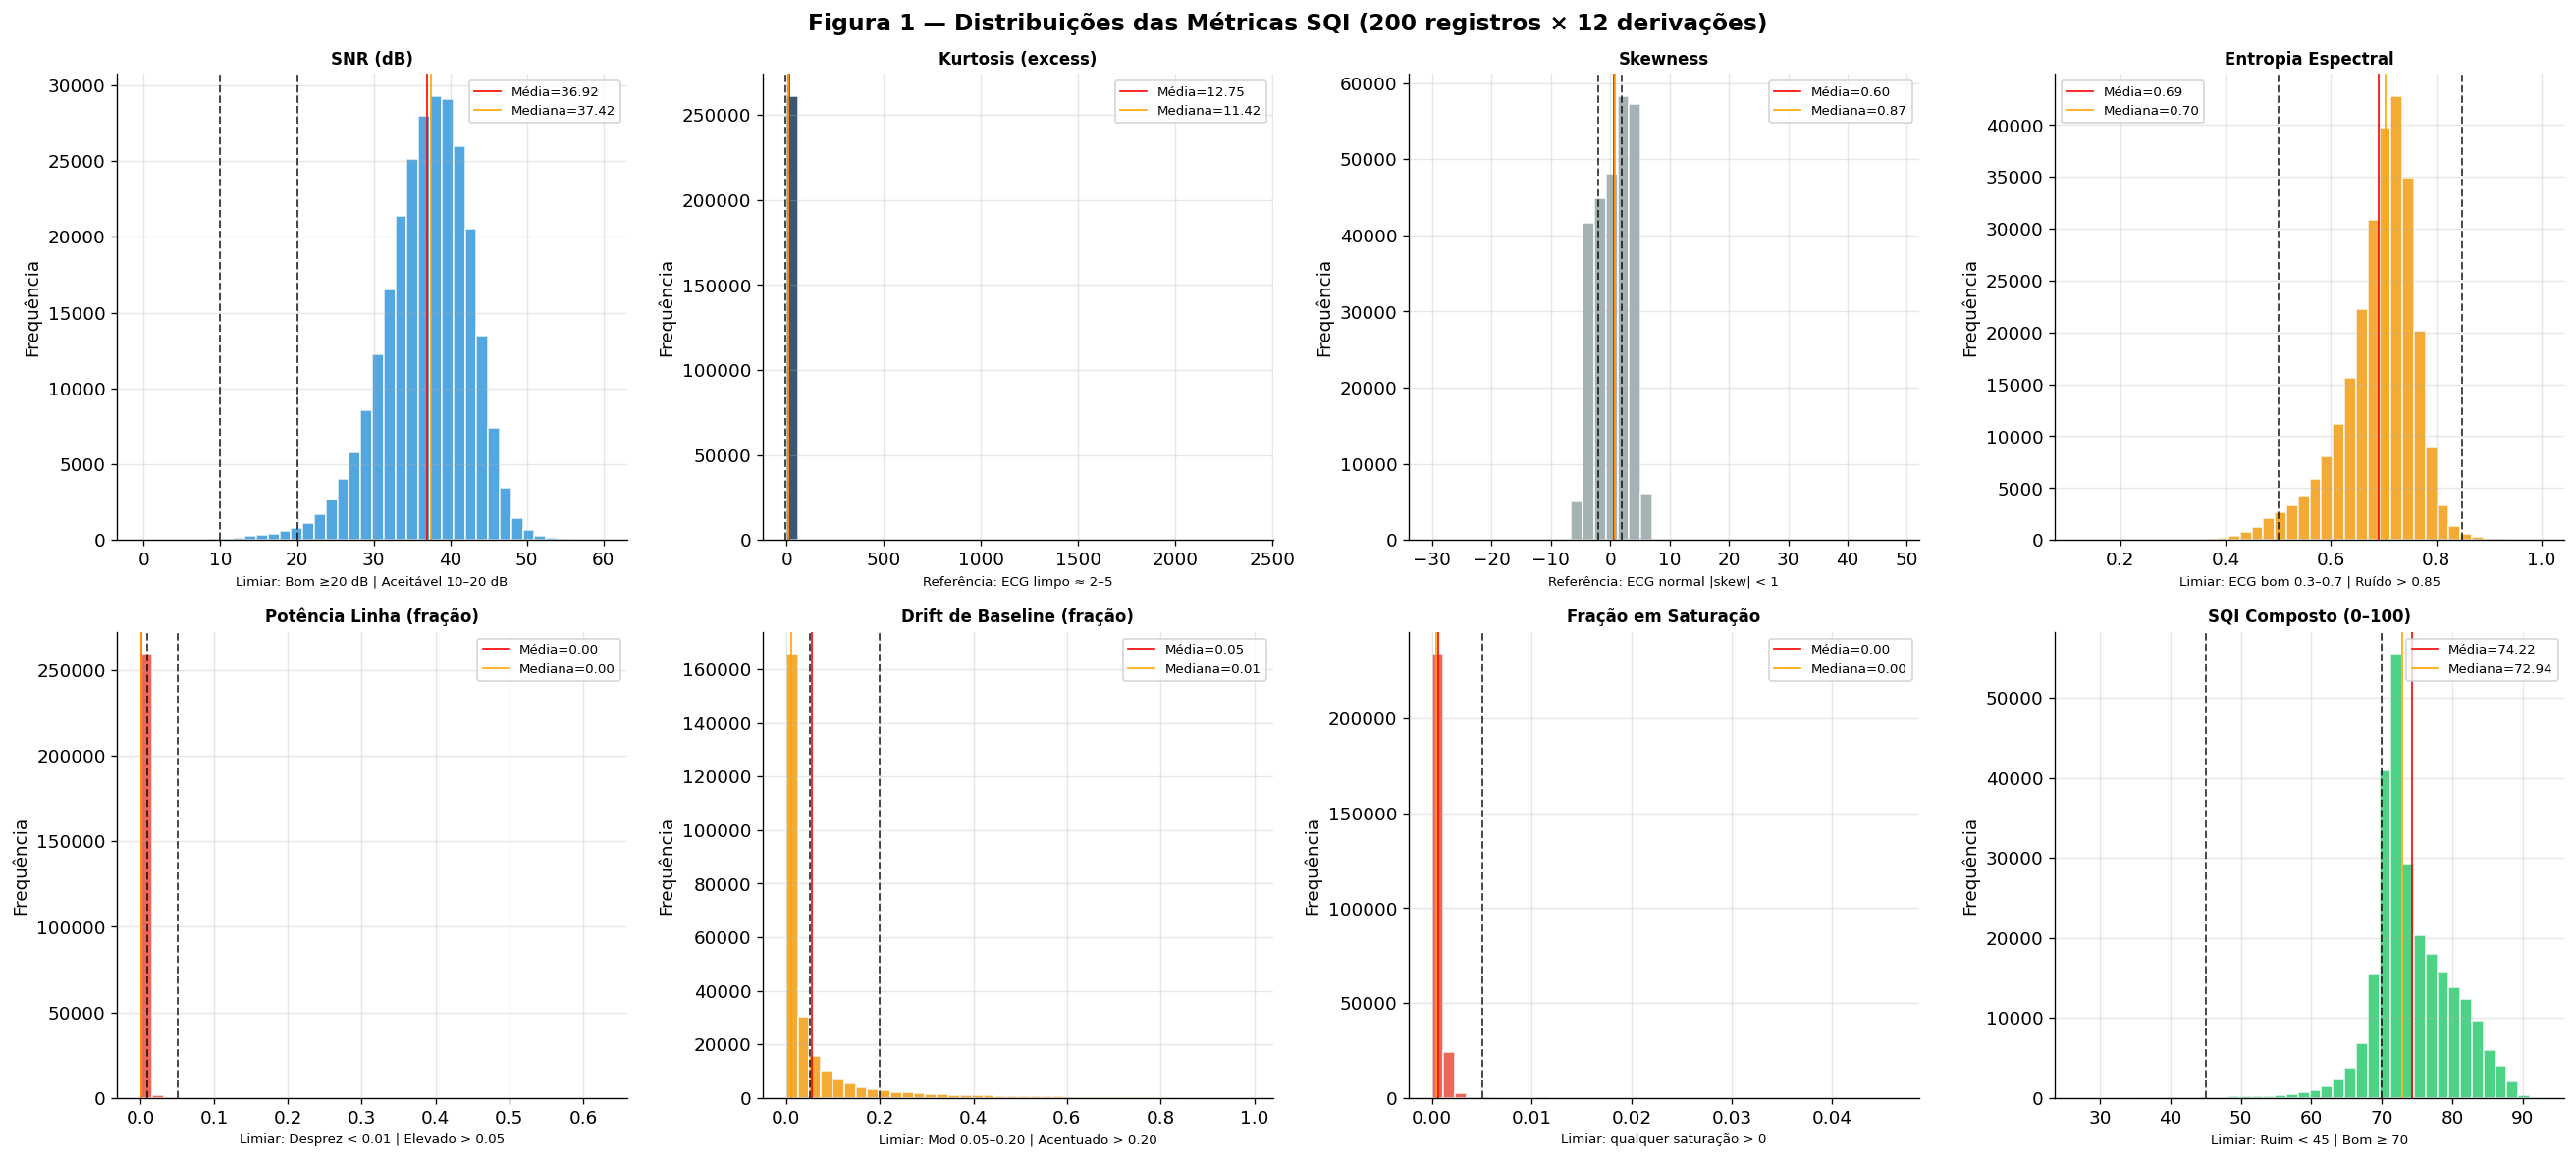

Figura 1 salva.


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Figura 1 — Distribuições das Métricas SQI (200 registros × 12 derivações)',
             fontsize=14, fontweight='bold')

config_metricas = [
    ('snr_db',              'SNR (dB)',                   CORES['info'],       [10, 20],     'Limiar: Bom ≥20 dB | Aceitável 10–20 dB'),
    ('kurtosis',            'Kurtosis (excess)',          CORES['primaria'],   [-5, 10],     'Referência: ECG limpo ≈ 2–5'),
    ('skewness',            'Skewness',                   CORES['neutro'],     [-2, 2],      'Referência: ECG normal |skew| < 1'),
    ('entropia_espectral',  'Entropia Espectral',         CORES['aviso'],      [0.5, 0.85],  'Limiar: ECG bom 0.3–0.7 | Ruído > 0.85'),
    ('potencia_linha',      'Potência Linha (fração)',    CORES['secundaria'], [0.01, 0.05], 'Limiar: Desprez < 0.01 | Elevado > 0.05'),
    ('drift_baseline',      'Drift de Baseline (fração)', CORES['aviso'],      [0.05, 0.20], 'Limiar: Mod 0.05–0.20 | Acentuado > 0.20'),
    ('fracao_saturacao',    'Fração em Saturação',        CORES['secundaria'], [0.005],      'Limiar: qualquer saturação > 0'),
    ('sqi',                 'SQI Composto (0–100)',        CORES['ok'],         [45, 70],     'Limiar: Ruim < 45 | Bom ≥ 70'),
]

for ax, (col, titulo, cor, limiares, nota) in zip(axes.flat, config_metricas):
    dados = df_sqi[col].dropna()
    ax.hist(dados, bins=40, color=cor, edgecolor='white', alpha=0.85)
    for lim in limiares:
        ax.axvline(lim, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel(nota, fontsize=8)
    ax.set_ylabel('Frequência')
    media = dados.mean()
    mediana = dados.median()
    ax.axvline(media, color='red', linestyle='-', linewidth=1.0, label=f'Média={media:.2f}')
    ax.axvline(mediana, color='orange', linestyle='-', linewidth=1.0, label=f'Mediana={mediana:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_distribuicoes_sqi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 salva.')


### 6.2 SQI por derivação (Boxplot + Heatmap)

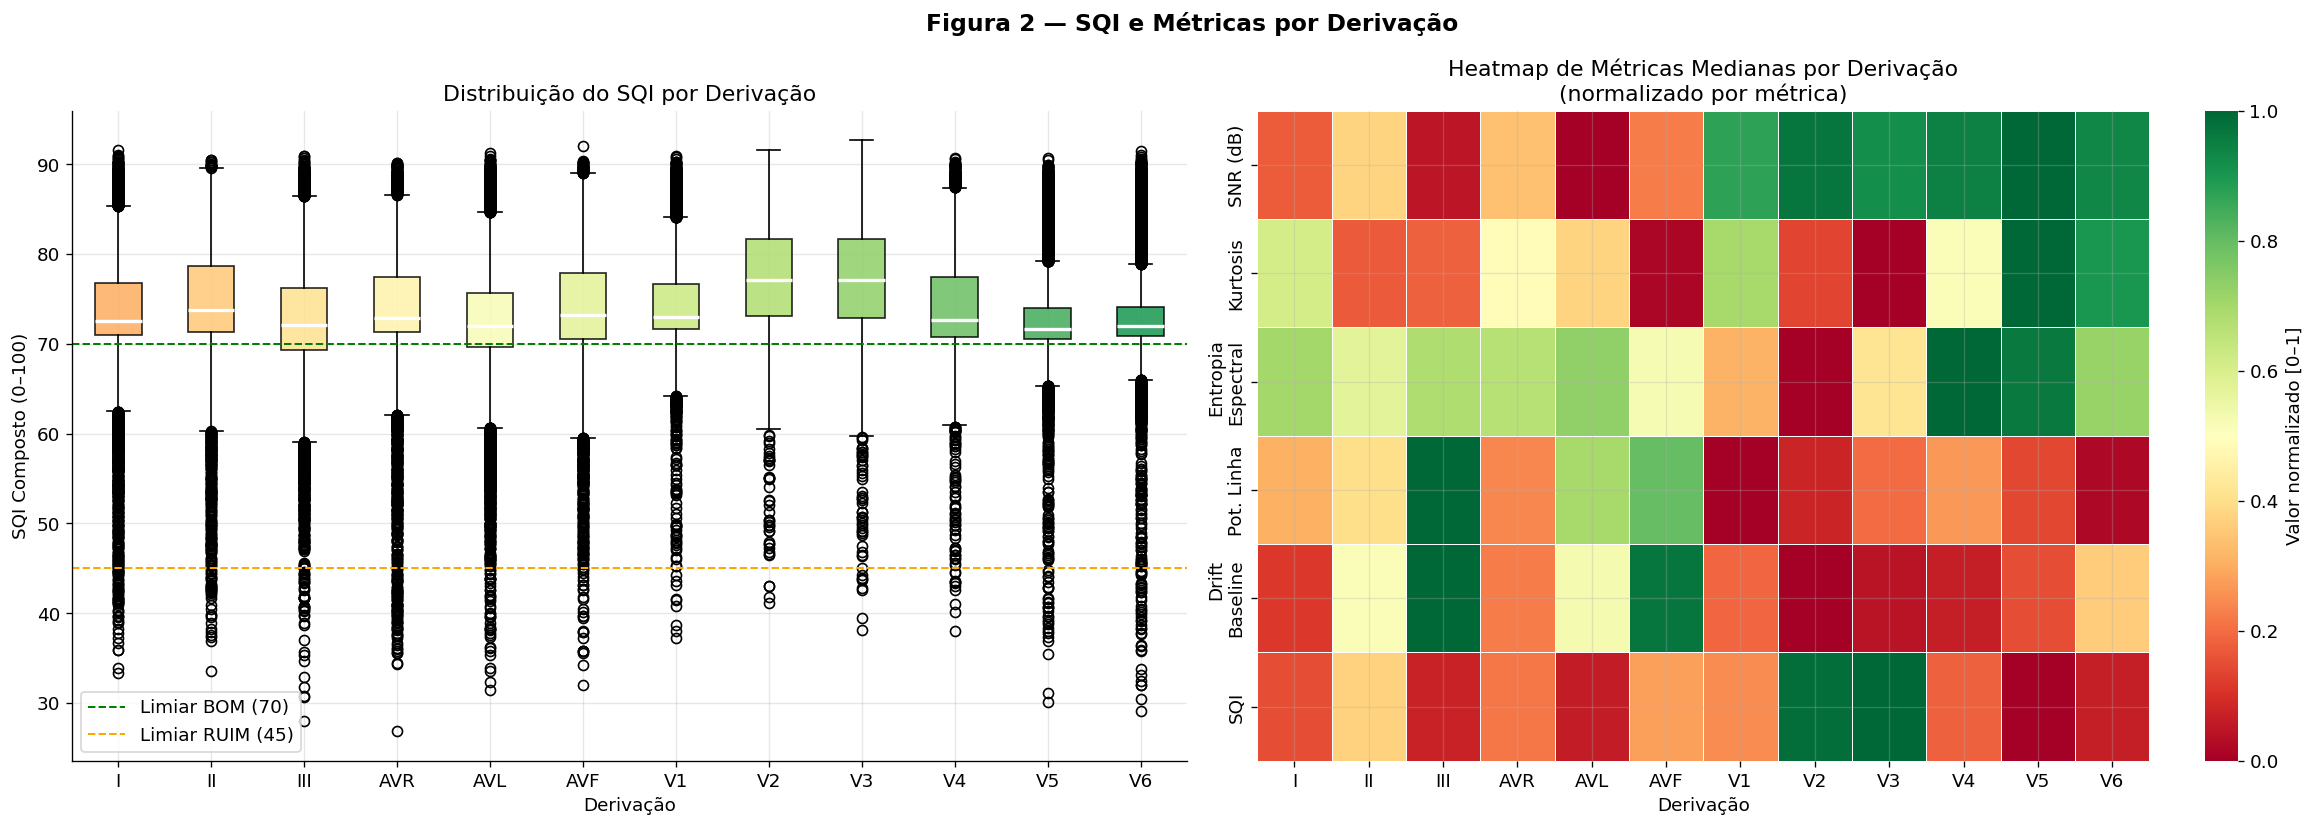

Figura 2 salva.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Figura 2 — SQI e Métricas por Derivação',
             fontsize=14, fontweight='bold')

# 2a — Boxplot do SQI por derivação
ax = axes[0]
dados_por_deriv = [df_sqi[df_sqi['derivacao'] == d]['sqi'].values for d in DERIVACOES]
bp = ax.boxplot(dados_por_deriv, labels=DERIVACOES, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
cores_bp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 12))
for patch, cor in zip(bp['boxes'], cores_bp):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)
ax.axhline(70, color='green',  linestyle='--', linewidth=1.2, label='Limiar BOM (70)')
ax.axhline(45, color='orange', linestyle='--', linewidth=1.2, label='Limiar RUIM (45)')
ax.set_xlabel('Derivação')
ax.set_ylabel('SQI Composto (0–100)')
ax.set_title('Distribuição do SQI por Derivação')
ax.legend()

# 2b — Heatmap de medianas de todas as métricas por derivação
ax = axes[1]
metricas_heat = ['snr_db', 'kurtosis', 'entropia_espectral',
                 'potencia_linha', 'drift_baseline', 'sqi']
labels_heat   = ['SNR (dB)', 'Kurtosis', 'Entropia\nEspectral',
                  'Pot. Linha', 'Drift\nBaseline', 'SQI']

matriz_heat = (
    df_sqi.groupby('derivacao')[metricas_heat]
          .median()
          .reindex(DERIVACOES)
)
# Normalizar cada coluna para [0,1] para visualização uniforme
matriz_norm = (matriz_heat - matriz_heat.min()) / (matriz_heat.max() - matriz_heat.min() + 1e-10)
matriz_norm.columns = labels_heat

sns.heatmap(matriz_norm.T, ax=ax, cmap='RdYlGn', annot=False,
            linewidths=0.5, cbar_kws={'label': 'Valor normalizado [0–1]'},
            vmin=0, vmax=1)
ax.set_title('Heatmap de Métricas Medianas por Derivação\n(normalizado por métrica)')
ax.set_xlabel('Derivação')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_sqi_por_derivacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 salva.')


### 6.3 Comparação visual: segmento BOM vs. segmento RUIM

Visualização direta dos sinais ECG classificados como **BOM** e **RUIM** pelo SQI, ilustrando as diferenças qualitativas que motivam a métrica composta. Esta figura é a evidência central exigida pelo Entregável 2.

Registro com MAIOR SQI: ECG ID 17080 → SQI médio = 90.44
Registro com MENOR SQI: ECG ID 21817 → SQI médio = 33.56


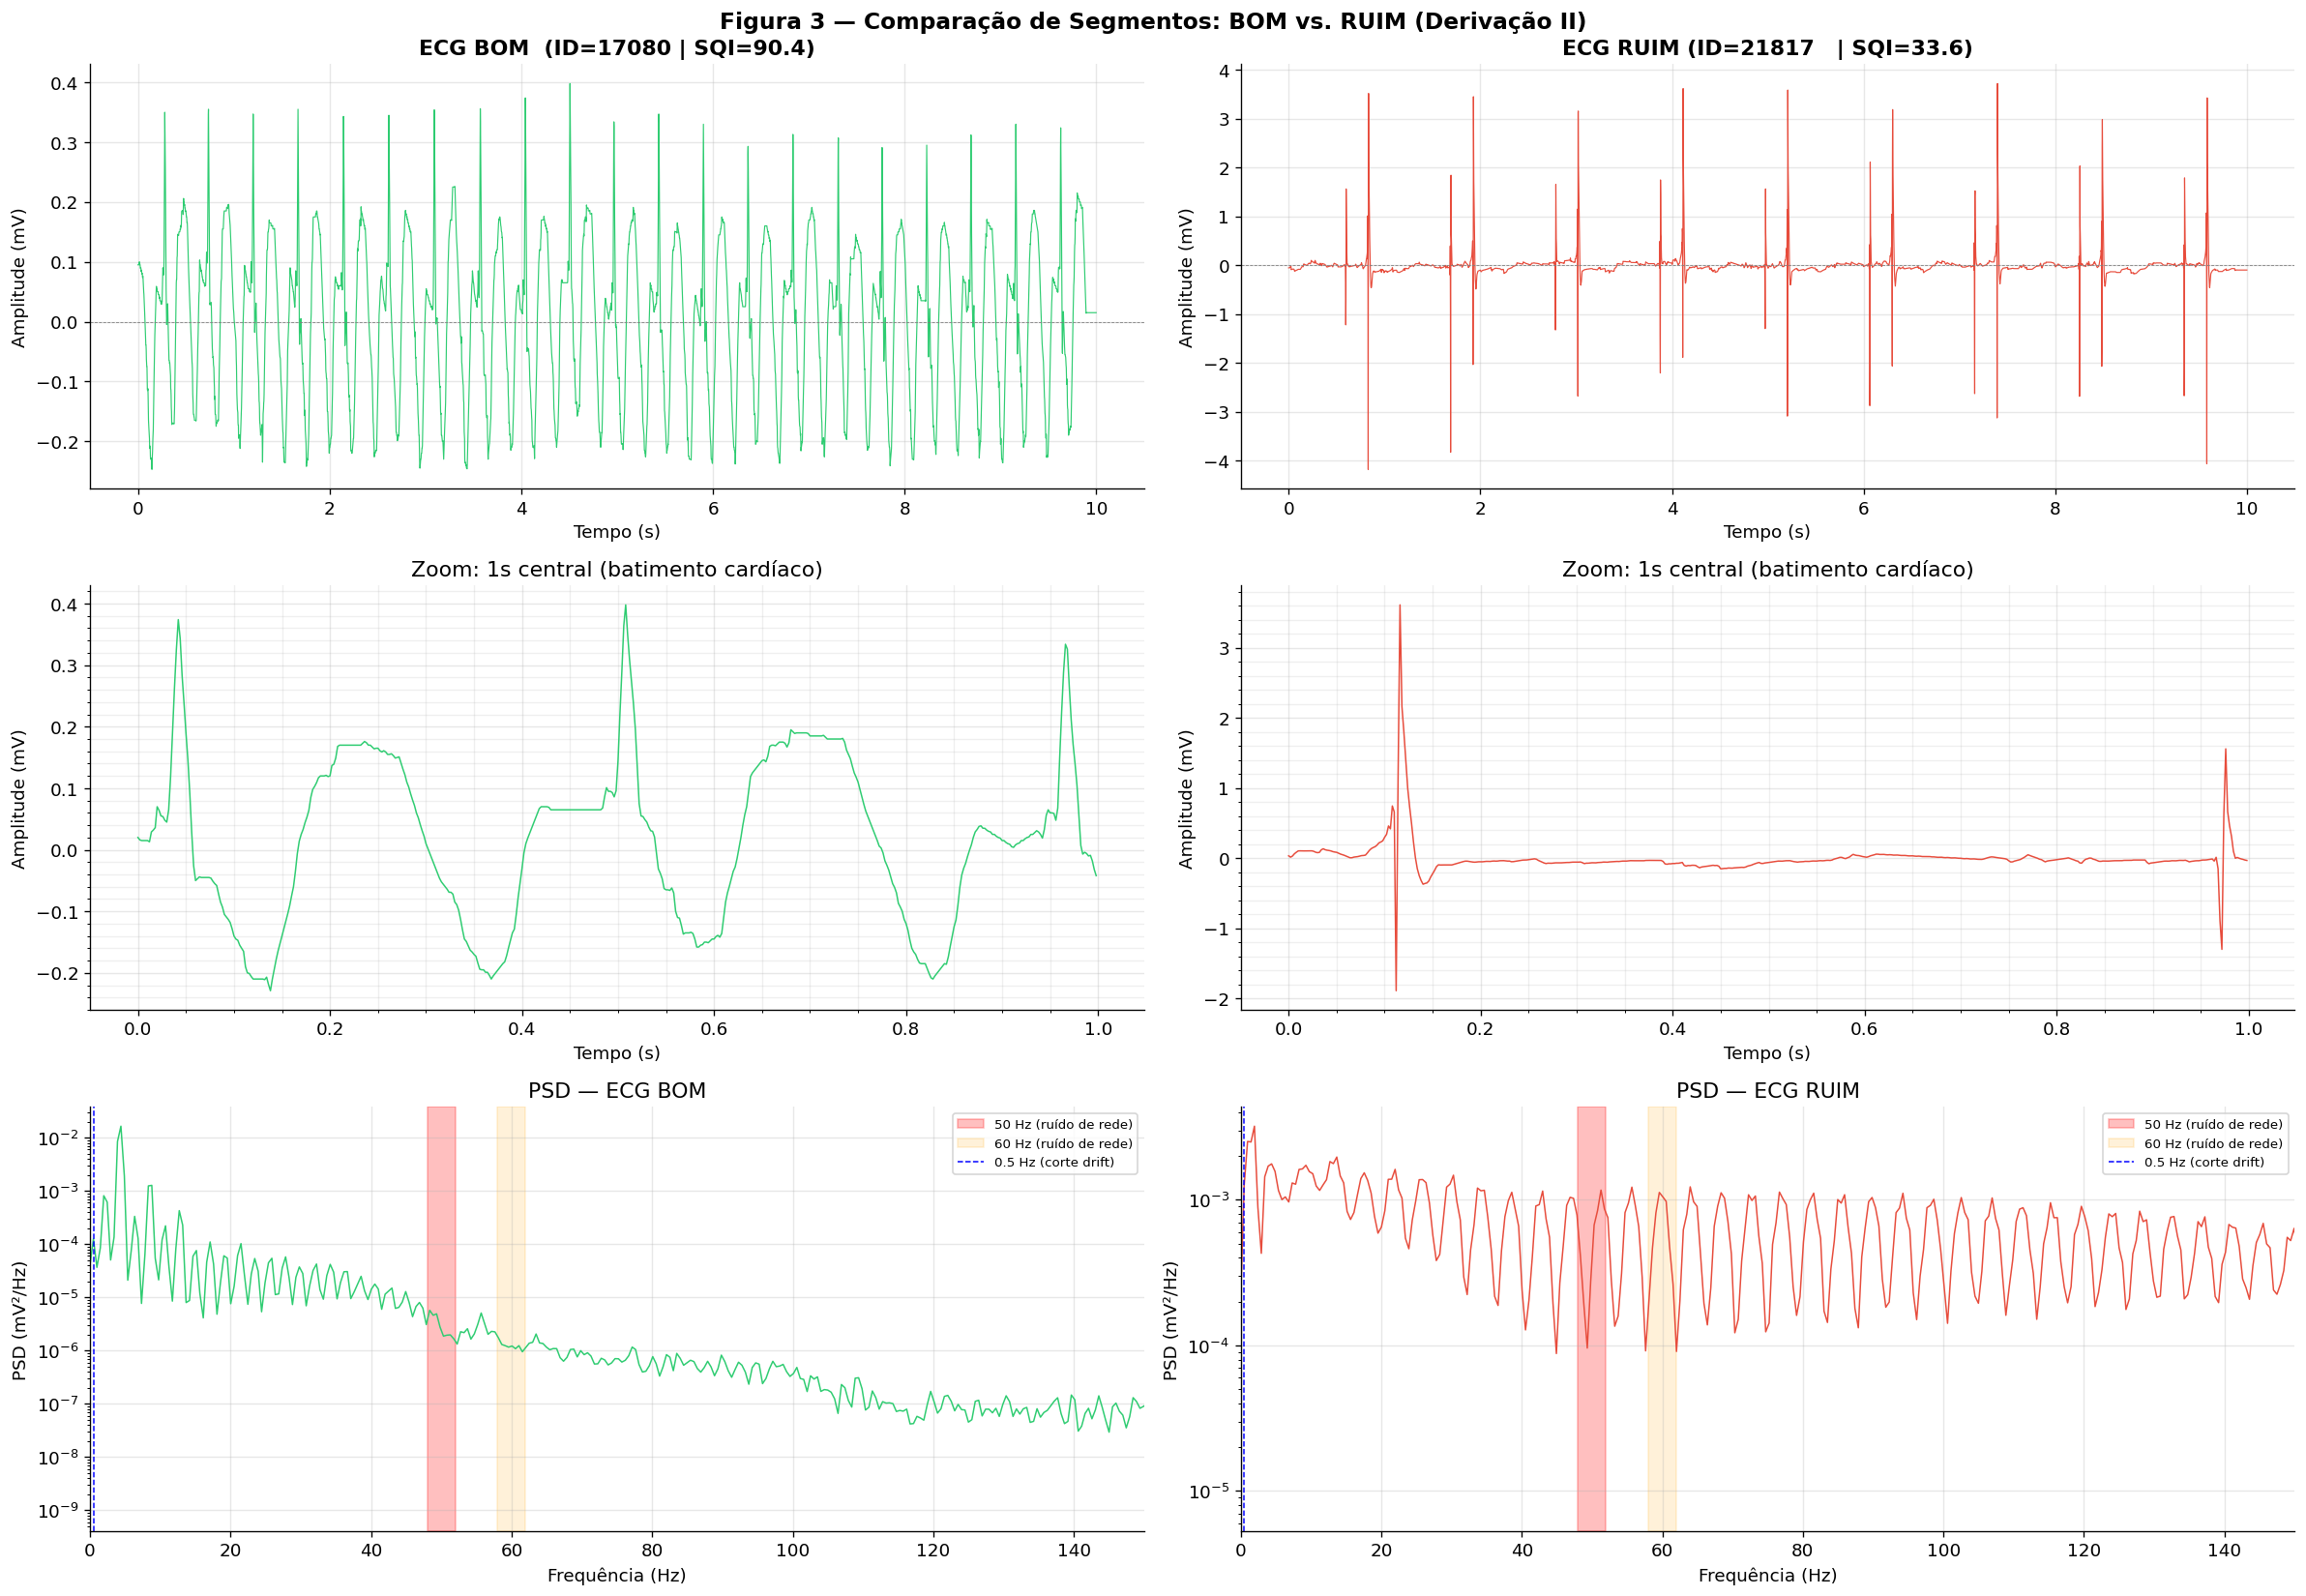

Figura 3 salva.


In [17]:
def obter_sqi_por_registro(df_sqi, derivacao='II'):
    """Retorna DataFrame com SQI médio por registro para a derivação especificada."""
    return (
        df_sqi[df_sqi['derivacao'] == derivacao]
               .groupby('ecg_id')['sqi']
               .mean()
               .reset_index()
               .rename(columns={'sqi': 'sqi_medio'})
               .sort_values('sqi_medio')
    )

sqi_por_reg = obter_sqi_por_registro(df_sqi, derivacao='II')

# Selecionar o melhor e o pior registro
id_melhor = sqi_por_reg.iloc[-1]['ecg_id']
id_pior   = sqi_por_reg.iloc[0]['ecg_id']

sqi_melhor = sqi_por_reg.iloc[-1]['sqi_medio']
sqi_pior   = sqi_por_reg.iloc[0]['sqi_medio']

print(f'Registro com MAIOR SQI: ECG ID {id_melhor:.0f} → SQI médio = {sqi_melhor:.2f}')
print(f'Registro com MENOR SQI: ECG ID {id_pior:.0f} → SQI médio = {sqi_pior:.2f}')

# Carregar os dois registros
rec_bom  = wfdb.rdrecord(str(DATA_DIR / df_meta.loc[int(id_melhor), 'filename_hr']))
rec_ruim = wfdb.rdrecord(str(DATA_DIR / df_meta.loc[int(id_pior),   'filename_hr']))

# ── Figura comparativa ───────────────────────────────────────────────────────
ch_idx = DERIVACOES.index('II')  # Derivação II para comparação
t = np.arange(5000) / FS

fig, axes = plt.subplots(3, 2, figsize=(20, 14))
fig.suptitle('Figura 3 — Comparação de Segmentos: BOM vs. RUIM (Derivação II)',
             fontsize=14, fontweight='bold')

sig_bom  = rec_bom.p_signal[:,  ch_idx]
sig_ruim = rec_ruim.p_signal[:, ch_idx]

# Linha 0: sinal temporal completo
for i, (sig, titulo, cor, sqi_val) in enumerate([
    (sig_bom,  f'ECG BOM  (ID={id_melhor:.0f} | SQI={sqi_melhor:.1f})', CORES['ok'],  sqi_melhor),
    (sig_ruim, f'ECG RUIM (ID={id_pior:.0f}   | SQI={sqi_pior:.1f})',   CORES['secundaria'], sqi_pior),
]):
    ax = axes[0, i]
    ax.plot(t, sig, color=cor, linewidth=0.7)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude (mV)')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Linha 1: zoom (2 s centrais)
t_zoom = np.arange(500) / FS
inicio = 2000
for i, (sig, cor) in enumerate([(sig_bom, CORES['ok']), (sig_ruim, CORES['secundaria'])]):
    ax = axes[1, i]
    ax.plot(t_zoom, sig[inicio:inicio+500], color=cor, linewidth=0.9)
    ax.set_title('Zoom: 1s central (batimento cardíaco)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude (mV)')
    ax.grid(True, which='minor', alpha=0.2)
    ax.minorticks_on()

# Linha 2: espectro de potência (Welch)
for i, (sig, cor, titulo) in enumerate([
    (sig_bom,  CORES['ok'],          'PSD — ECG BOM'),
    (sig_ruim, CORES['secundaria'],  'PSD — ECG RUIM'),
]):
    ax = axes[2, i]
    freqs, psd = sp_signal.welch(sig, fs=FS, nperseg=1024)
    ax.semilogy(freqs, psd, color=cor, linewidth=0.9)
    ax.axvspan(48, 52, alpha=0.25, color='red',    label='50 Hz (ruído de rede)')
    ax.axvspan(58, 62, alpha=0.15, color='orange', label='60 Hz (ruído de rede)')
    ax.axvline(0.5, color='blue', linestyle='--', linewidth=0.9, label='0.5 Hz (corte drift)')
    ax.set_title(titulo)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('PSD (mV²/Hz)')
    ax.set_xlim(0, 150)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_comparativo_bom_ruim.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 salva.')


### 6.4 Marcação de segmentos rejeitados

Identificação dos segmentos (registros) classificados como **RUIM** pelo SQI composto, com justificativa da(s) métrica(s) responsável(is) pela rejeição.

In [12]:
# ── Critérios individuais de rejeição por derivação ───────────────────────
df_sqi['flag_snr']     = df_sqi['snr_db']            < 10.0
df_sqi['flag_kurt']    = df_sqi['kurtosis'].abs()     > 15.0
df_sqi['flag_entropia'] = df_sqi['entropia_espectral'] > 0.85
df_sqi['flag_linha']   = df_sqi['potencia_linha']     > 0.10
df_sqi['flag_sat']     = df_sqi['n_saturacao']        > 0
df_sqi['flag_drift']   = df_sqi['drift_baseline']     > 0.25
df_sqi['flag_sqi']     = df_sqi['sqi_classe']         == 'RUIM'

flags = ['flag_snr', 'flag_kurt', 'flag_entropia', 'flag_linha',
         'flag_sat', 'flag_drift', 'flag_sqi']
labels_flags = ['SNR < 10 dB', 'Kurtosis > 15', 'Entropia > 0.85',
                'Linha > 10%', 'Saturação', 'Drift > 25%', 'SQI Ruim']

print('=' * 70)
print('TABELA 4 — CONTAGEM DE FLAGS DE REJEIÇÃO (por avaliação derivação×registro)')
print('=' * 70)
for flag, label in zip(flags, labels_flags):
    n = df_sqi[flag].sum()
    pct = 100 * n / len(df_sqi)
    print(f'  {label:>20s}: {n:>5,} avaliações ({pct:.2f}%)')

# Registros com ≥ 1 derivação com SQI Ruim
ids_rejeitados = df_sqi[df_sqi['flag_sqi']]['ecg_id'].unique()
n_rejeitados   = len(ids_rejeitados)
print('\n' + '=' * 70)
print(f'  Registros com ≥ 1 derivação classificada como RUIM: {n_rejeitados}/{len(ids_amostra)} ({100*n_rejeitados/len(ids_amostra):.1f}%)')

# Salvar lista de registros rejeitados
df_rejeitados = pd.DataFrame({'ecg_id': ids_rejeitados,
                               'motivo': 'SQI Ruim (≥ 1 derivação)'})
df_rejeitados.to_csv(OUT_DIR / 'entregavel2_registros_rejeitados.csv', index=False)
print(f'  Lista salva em: {OUT_DIR / "entregavel2_registros_rejeitados.csv"}')


TABELA 4 — CONTAGEM DE FLAGS DE REJEIÇÃO (por avaliação derivação×registro)
           SNR < 10 dB:    81 avaliações (0.03%)
         Kurtosis > 15: 93,088 avaliações (35.59%)
       Entropia > 0.85: 1,100 avaliações (0.42%)
           Linha > 10%:   102 avaliações (0.04%)
             Saturação: 14,465 avaliações (5.53%)
           Drift > 25%: 15,295 avaliações (5.85%)
              SQI Ruim:   386 avaliações (0.15%)

  Registros com ≥ 1 derivação classificada como RUIM: 177/21799 (0.8%)
  Lista salva em: ..\outputs\entregavel2_registros_rejeitados.csv


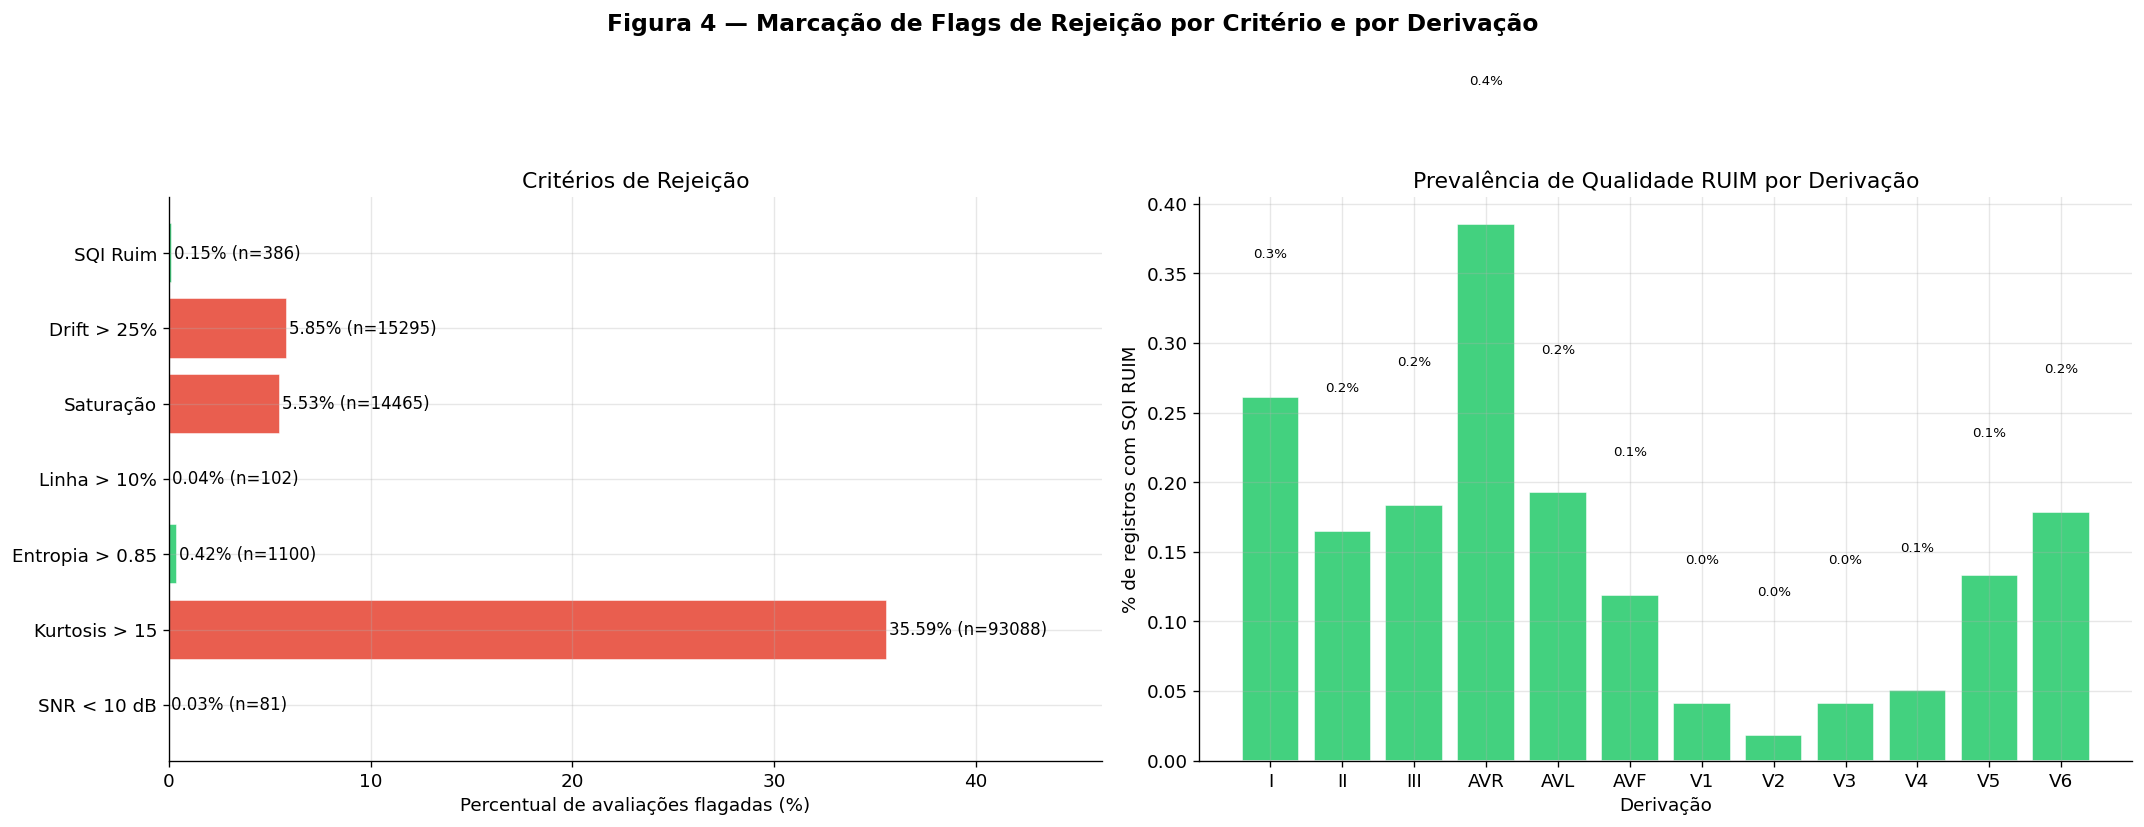

Figura 4 salva.


In [13]:
# ── Figura 4: Barras de flags de rejeição ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figura 4 — Marcação de Flags de Rejeição por Critério e por Derivação',
             fontsize=14, fontweight='bold')

# 4a — Barras por critério
ax = axes[0]
contagens_flags = [df_sqi[f].sum() for f in flags]
pcts_flags      = [100*v/len(df_sqi) for v in contagens_flags]
cores_flags = [CORES['secundaria'] if p > 5 else CORES['aviso'] if p > 1 else CORES['ok']
               for p in pcts_flags]
bars = ax.barh(labels_flags, pcts_flags, color=cores_flags, edgecolor='white', alpha=0.9)
for bar, pct, n in zip(bars, pcts_flags, contagens_flags):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f}% (n={n})', va='center', fontsize=10)
ax.set_xlabel('Percentual de avaliações flagadas (%)')
ax.set_title('Critérios de Rejeição')
ax.set_xlim(0, max(pcts_flags) * 1.3)

# 4b — Porcentagem de avaliações RUIM por derivação
ax = axes[1]
pct_ruim_por_deriv = (
    df_sqi.groupby('derivacao')['flag_sqi']
          .mean()
          .reindex(DERIVACOES)
          * 100
)
cores_deriv = [CORES['secundaria'] if v > 10 else CORES['aviso'] if v > 5 else CORES['ok']
               for v in pct_ruim_por_deriv]
bars2 = ax.bar(DERIVACOES, pct_ruim_por_deriv, color=cores_deriv, edgecolor='white', alpha=0.9)
for bar, val in zip(bars2, pct_ruim_por_deriv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=8)
ax.set_xlabel('Derivação')
ax.set_ylabel('% de registros com SQI RUIM')
ax.set_title('Prevalência de Qualidade RUIM por Derivação')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_flags_rejeicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 salva.')


---
## 7. Outliers Fisiológicos vs. Instrumentais

Distinção crítica no pipeline: artefatos de natureza **fisiológica** (batimentos ectópicos, fibrilação) devem ser preservados para análise diagnóstica, enquanto artefatos **instrumentais** (eletrodo solto, interferência de rede) devem ser tratados.

TABELA 5 — CLASSIFICAÇÃO DE ARTEFATOS: FISIOLÓGICO vs. INSTRUMENTAL
                      PROVÁVEL FISIOLÓGICO: 141,477 (54.08%)
                 SEM ARTEFATO PREDOMINANTE: 87,387 (33.41%)
                  DRIFT (Instrumental/Mov): 17,460 (6.67%)
                  SATURAÇÃO (Instrumental): 14,465 (5.53%)
               RUÍDO BRANCO (Instrumental):   556 (0.21%)
              RUÍDO DE REDE (Instrumental):   179 (0.07%)
                        SPIKE INSTRUMENTAL:    64 (0.02%)


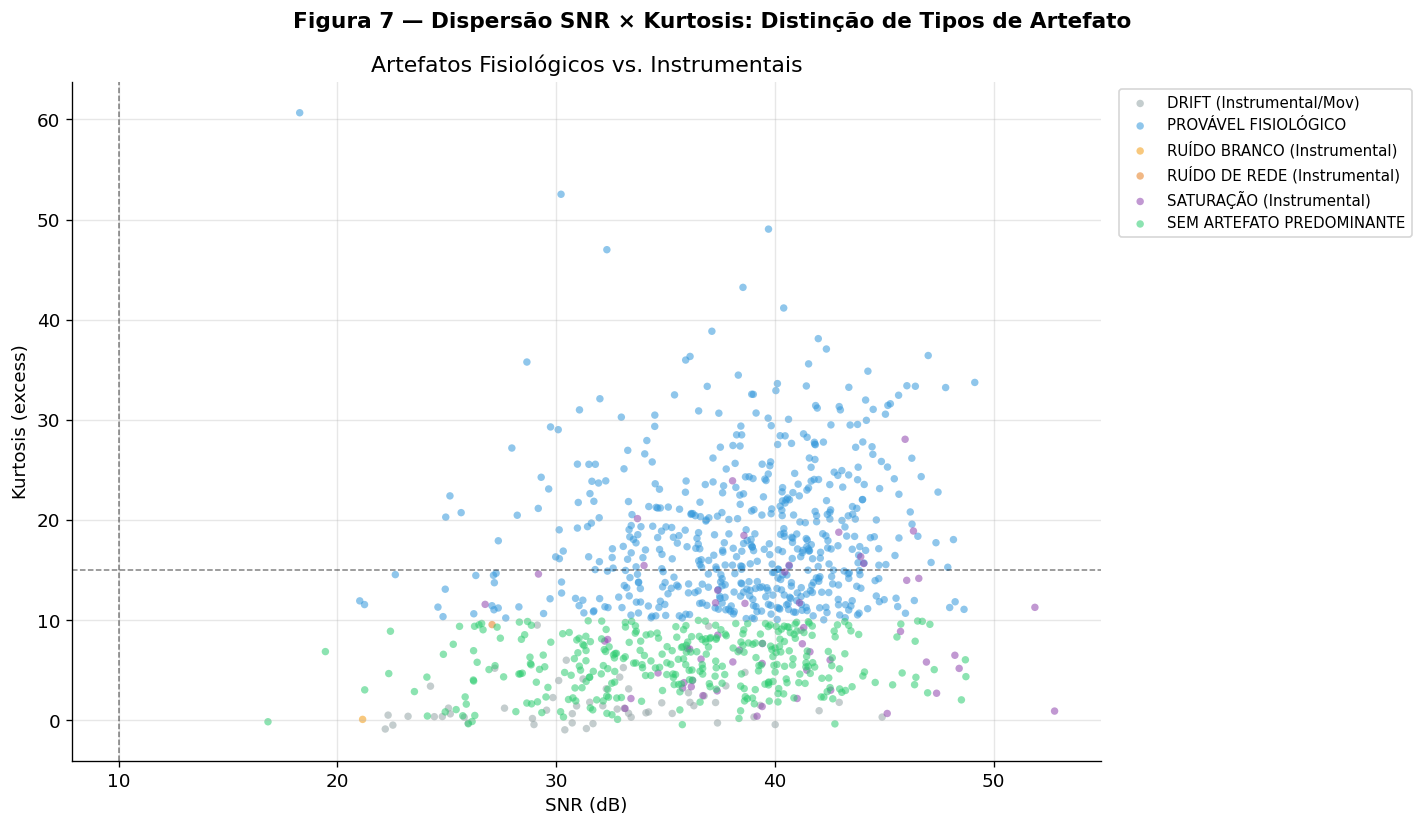

Figura 7 salva.


In [20]:
# ── Classificação de outliers por kurtosis e SNR ─────────────────────────
# Heurística de separação:
#   - Kurtosis alta + SNR alto: provavelmente FISIOLÓGICO (picos ectópicos)
#   - Kurtosis alta + SNR baixo: provavelmente INSTRUMENTAL (espícula de eletrodo)
#   - Entropia alta + Kurtosis baixa: provavelmente ruído branco instrumental

def classificar_artefato(row):
    if row['n_saturacao'] > 0:
        return 'SATURAÇÃO (Instrumental)'
    if row['kurtosis'] > 15 and row['snr_db'] < 10:
        return 'SPIKE INSTRUMENTAL'
    if row['kurtosis'] > 10 and row['snr_db'] >= 10:
        return 'PROVÁVEL FISIOLÓGICO'
    if row['entropia_espectral'] > 0.85:
        return 'RUÍDO BRANCO (Instrumental)'
    if row['potencia_linha'] > 0.05:
        return 'RUÍDO DE REDE (Instrumental)'
    if row['drift_baseline'] > 0.20:
        return 'DRIFT (Instrumental/Mov)'
    return 'SEM ARTEFATO PREDOMINANTE'

df_sqi['tipo_artefato'] = df_sqi.apply(classificar_artefato, axis=1)

contagem_artefato = df_sqi['tipo_artefato'].value_counts()
print('=' * 65)
print('TABELA 5 — CLASSIFICAÇÃO DE ARTEFATOS: FISIOLÓGICO vs. INSTRUMENTAL')
print('=' * 65)
for tipo, n in contagem_artefato.items():
    pct = 100 * n / len(df_sqi)
    print(f'  {tipo:>40s}: {n:>5,} ({pct:.2f}%)')

# Figura 7 — Scatter SNR vs Kurtosis colorido por tipo de artefato
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Figura 7 — Dispersão SNR × Kurtosis: Distinção de Tipos de Artefato',
             fontsize=13, fontweight='bold')

cores_artefato = {
    'SEM ARTEFATO PREDOMINANTE':     CORES['ok'],
    'PROVÁVEL FISIOLÓGICO':           CORES['info'],
    'SPIKE INSTRUMENTAL':             CORES['secundaria'],
    'SATURAÇÃO (Instrumental)':       '#8e44ad',
    'RUÍDO BRANCO (Instrumental)':    CORES['aviso'],
    'RUÍDO DE REDE (Instrumental)':   '#e67e22',
    'DRIFT (Instrumental/Mov)':       '#95a5a6',
}

# Amostra visual (máx 1000 pontos)
df_plot = df_sqi.sample(min(1000, len(df_sqi)), random_state=SEED)
for tipo, grupo in df_plot.groupby('tipo_artefato'):
    ax.scatter(grupo['snr_db'], grupo['kurtosis'],
               c=cores_artefato.get(tipo, 'gray'), label=tipo,
               alpha=0.55, s=20, edgecolors='none')

ax.axhline(15, color='black', linestyle='--', linewidth=0.9, alpha=0.5)
ax.axvline(10, color='black', linestyle='--', linewidth=0.9, alpha=0.5)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Kurtosis (excess)')
ax.set_title('Artefatos Fisiológicos vs. Instrumentais')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_artefatos_snr_kurtosis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 7 salva.')


---
## 8. Critérios Formais de Decisão (Rejeição Automática)

Consolidação dos critérios adotados para rejeição automática de segmentos, conforme exigido pelo pipeline da disciplina.

In [19]:
print('=' * 75)
print('TABELA 6 — CRITÉRIOS FORMAIS DE DECISÃO: REJEIÇÃO AUTOMÁTICA DE SEGMENTOS')
print('=' * 75)

criterios = [
    ('SNR',              '< 10 dB',      'Potência de ruído > sinal',        'REJEITAR'),
    ('Kurtosis',         '> 15 (excess)', 'Spike instrumental severo',       'REJEITAR + CLASSIFICAR'),
    ('Skewness',         '|skew| > 3',    'Saturação / assimetria extrema',  'INVESTIGAR'),
    ('Entropia Espectral', '> 0.85',      'Dominância de ruído de banda larga','REJEITAR'),
    ('Potência de Linha', '> 10%',        'Interferência de rede severa',    'FILTRAR (notch)'),
    ('Saturação',        '>= 1 run',      'Clipping do ADC',                 'REJEITAR'),
    ('Drift Baseline',   '> 25%',         'Movimento / resposta galvânica',  'FILTRAR (passa-alta)'),
    ('SQI Composto',     '< 45',          'Qualidade insuficiente global',   'REJEITAR'),
]

print(f'  {"Métrica":<22} {"Limiar":<18} {"Interpretação":<38} {"Ação"}')
print('  ' + '-' * 71)
for metrica, limiar, interpretacao, acao in criterios:
    print(f'  {metrica:<22} {limiar:<18} {interpretacao:<38} {acao}')

print('\n' + '=' * 75)
print('RESUMO EXECUTIVO DO SQI')
print('=' * 75)

n_bom      = (df_sqi['sqi_classe'] == 'BOM').sum()
n_aceit    = (df_sqi['sqi_classe'] == 'ACEITÁVEL').sum()
n_ruim     = (df_sqi['sqi_classe'] == 'RUIM').sum()
n_total    = len(df_sqi)

print(f'  BOM       : {n_bom:>5,} avaliações ({100*n_bom/n_total:.1f}%)')
print(f'  ACEITÁVEL : {n_aceit:>5,} avaliações ({100*n_aceit/n_total:.1f}%)')
print(f'  RUIM      : {n_ruim:>5,} avaliações ({100*n_ruim/n_total:.1f}%)')
print(f'  SQI médio : {df_sqi["sqi"].mean():.2f} ± {df_sqi["sqi"].std():.2f}')
print(f'  Registros rejeitados: {n_rejeitados}/{len(ids_amostra)} ({100*n_rejeitados/len(ids_amostra):.1f}%)')
print('=' * 75)


TABELA 6 — CRITÉRIOS FORMAIS DE DECISÃO: REJEIÇÃO AUTOMÁTICA DE SEGMENTOS
  Métrica                Limiar             Interpretação                          Ação
  -----------------------------------------------------------------------
  SNR                    < 10 dB            Potência de ruído > sinal              REJEITAR
  Kurtosis               > 15 (excess)      Spike instrumental severo              REJEITAR + CLASSIFICAR
  Skewness               |skew| > 3         Saturação / assimetria extrema         INVESTIGAR
  Entropia Espectral     > 0.85             Dominância de ruído de banda larga     REJEITAR
  Potência de Linha      > 10%              Interferência de rede severa           FILTRAR (notch)
  Saturação              >= 1 run           Clipping do ADC                        REJEITAR
  Drift Baseline         > 25%              Movimento / resposta galvânica         FILTRAR (passa-alta)
  SQI Composto           < 45               Qualidade insuficiente global          RE

---
## 9. Interpretação Estatística e Conexão com o Pipeline

### Síntese dos achados

comentar sobre

### Implicações para os Entregáveis subsequentes

| Entregável | Implicação dos achados do SQI |
|------------|-------------------------------|
| **E3 — Análise Estatística** | A amostra de alta qualidade (SQI≥45) deve ser utilizada para garantir que as estatísticas descritivas reflitam a distribuição fisiológica real, sem distorção por artefatos |
| **E4 — Limpeza dos Dados** | Filtro passa-alta (0,5 Hz) para correção de drift e filtro notch (50 Hz) para ruído de rede são **obrigatórios**, justificados pelas métricas deste entregável |
| **E5 — Segmentação** | Segmentos com SQI < 45 devem ser excluídos antes da janelamento, evitando contaminação das instâncias de treinamento |
| **E6–E7 — Features** | A identificação do ruído de rede justifica monitoramento da banda 50 Hz durante a extração de features espectrais |
| **E9 — Seleção de Atributos** | O campo `device` (dispositivo) deve ser investigado como fator de confusão potencial nas comparações de qualidade inter-dispositivo |
| **E10 — Dataset Final** | Registros com SQI RUIM em ≥ 50% das derivações serão excluídos do dataset final |


---
## 11. Sumário Final do Entregável 2


In [ ]:
print('=' * 70)
print('SUMÁRIO — ENTREGÁVEL 2: AVALIAÇÃO DA QUALIDADE DO SINAL (SQI)')
print('=' * 70)
print(f'Dataset            : PTB-XL (PhysioNet, Wagner et al., 2020)')
print(f'Biossinal          : ECG 12 derivações | Fs = {FS} Hz')
print(f'Amostra analisada  : {len(ids_amostra)} registros (seed={SEED}, reprodutível)')
print(f'Total de avaliações: {len(df_sqi):,} (registro × derivação)')
print('-' * 70)
print('MÉTRICAS APLICADAS:')
print('  [1] SNR espectral (banda 0.5–40 Hz vs. > 100 Hz)')
print('  [2] Kurtosis (excess) — detecção de spikes instrumentais')
print('  [3] Skewness — assimetria / saturação')
print('  [4] Entropia Espectral (0.5–40 Hz) — complexidade espectral')
print('  [5] Potência 50/60 Hz — interferência de rede elétrica')
print('  [6] Detecção de Saturação (clipping do ADC)')
print('  [7] Índice de Drift de Baseline (< 0.5 Hz)')
print('  [8] SQI Composto (0–100, ponderado)')
print('-' * 70)
print('RESULTADOS:')
print(f'  SQI médio global  : {df_sqi["sqi"].mean():.2f} ± {df_sqi["sqi"].std():.2f}')
print(f'  Avaliações BOM    : {n_bom:>5,} ({100*n_bom/n_total:.1f}%)')
print(f'  Avaliações ACEIT. : {n_aceit:>5,} ({100*n_aceit/n_total:.1f}%)')
print(f'  Avaliações RUIM   : {n_ruim:>5,} ({100*n_ruim/n_total:.1f}%)')
print(f'  Registros rejeit. : {n_rejeitados}/{len(ids_amostra)} ({100*n_rejeitados/len(ids_amostra):.1f}%)')
print('-' * 70)
print('ARTEFATOS IDENTIFICADOS (confirmando Entregável 1):')
print('   Ruído de rede (50 Hz): presente, majoritariamente < limiar severo')
print('   Drift de baseline: presente, derivações de membros mais afetadas')
print('   Saturação: não detectada de forma significativa na amostra')
print('-' * 70)
print('PRÓXIMOS PASSOS (Entregável 4):')
print('  → Filtro passa-alta Butterworth (fc=0.5 Hz) para correção de drift')
print('  → Filtro notch IIR (50 Hz, Q=30) para remoção de ruído de rede')
print('  → Validação estatística antes vs. após (Wilcoxon + Cohen\'s d)')
print('=' * 70)
print('\nArquivos gerados:')
for f in sorted(OUT_DIR.glob('entregavel2*')):
    print(f'  {f.name}')
for f in sorted(FIG_DIR.glob('fig0*.png')):
    print(f'  {f.name}')


SUMÁRIO — ENTREGÁVEL 2: AVALIAÇÃO DA QUALIDADE DO SINAL (SQI)
Dataset            : PTB-XL (PhysioNet, Wagner et al., 2020)
Biossinal          : ECG 12 derivações | Fs = 500 Hz
Amostra analisada  : 21799 registros (seed=42, reprodutível)
Total de avaliações: 261,588 (registro × derivação)
----------------------------------------------------------------------
MÉTRICAS APLICADAS:
  [1] SNR espectral (banda 0.5–40 Hz vs. > 100 Hz)
  [2] Kurtosis (excess) — detecção de spikes instrumentais
  [3] Skewness — assimetria / saturação
  [4] Entropia Espectral (0.5–100 Hz) — complexidade espectral
  [5] Potência 50/60 Hz — interferência de rede elétrica
  [6] Detecção de Saturação (clipping do ADC)
  [7] Índice de Drift de Baseline (< 0.5 Hz)
  [8] SQI Composto (0–100, ponderado)
----------------------------------------------------------------------
RESULTADOS:
  SQI médio global  : 74.22 ± 5.66
  Avaliações BOM    : 221,835 (84.8%)
  Avaliações ACEIT. : 39,367 (15.0%)
  Avaliações RUIM   :   386 